Unsupervised learining

In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [251]:
x,y_true=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [252]:
df=pd.DataFrame(x, columns=["Feature_1","Feature_2"])

In [253]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [254]:
scaler=StandardScaler()
sc=scaler.fit_transform(df)

In [255]:
wcss=[]
k_range=range(1,11)

In [256]:
for k in k_range:
     kmeans=KMeans(n_clusters=k,random_state=42)
     kmeans.fit(sc)
     wcss.append(kmeans.inertia_)

In [257]:
wcss

[1000.0000000000001,
 297.8954141051722,
 11.575484723104982,
 9.752067977356843,
 8.25717527244628,
 6.917577320416798,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130397]

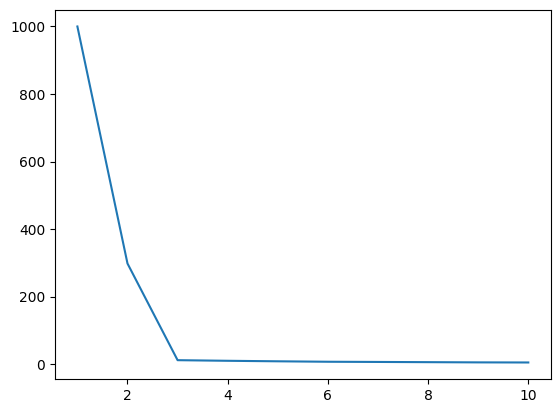

In [258]:
plt.plot(k_range,wcss)

In [259]:
kmeans_final=KMeans(n_clusters=3,random_state=42)

In [260]:
cluster_label=kmeans_final.fit_predict(sc)

In [261]:
cluster_label

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [262]:
df["cluster"]=cluster_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

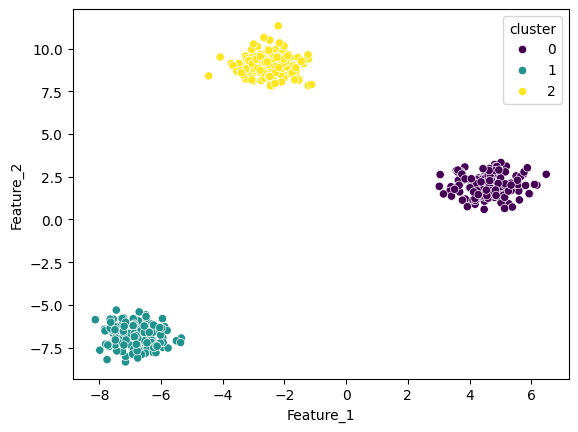

In [263]:
sns.scatterplot(x=df["Feature_1"],
                y=df["Feature_2"],
                hue=df["cluster"],
                palette="viridis")

DBSCAN

In [264]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans,DBSCAN

In [265]:
x,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)

In [266]:
df=pd.DataFrame(x, columns=["Feature_1","Feature_2"])

In [267]:
scaler=StandardScaler()
sc=scaler.fit_transform(df)

In [268]:
kmeans_final=KMeans(n_clusters=3,random_state=42)
cluster_label=kmeans_final.fit_predict(sc)
df["cluster"]=cluster_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

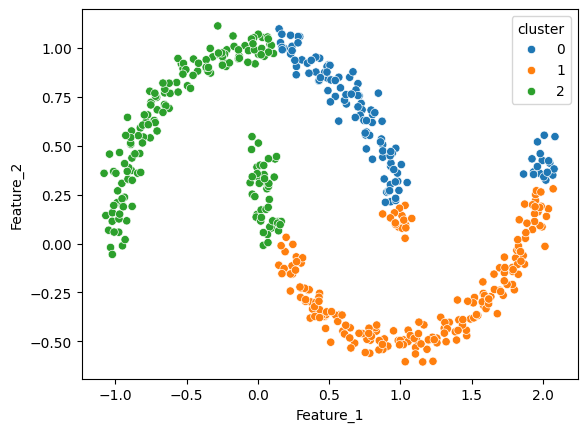

In [269]:
sns.scatterplot(x=df["Feature_1"],
                y=df["Feature_2"],
                hue=df["cluster"],
                palette="tab10")

In [270]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
dbscan_label=dbscan.fit_predict(sc)

In [271]:
df["dbscan_cluster"]=dbscan_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

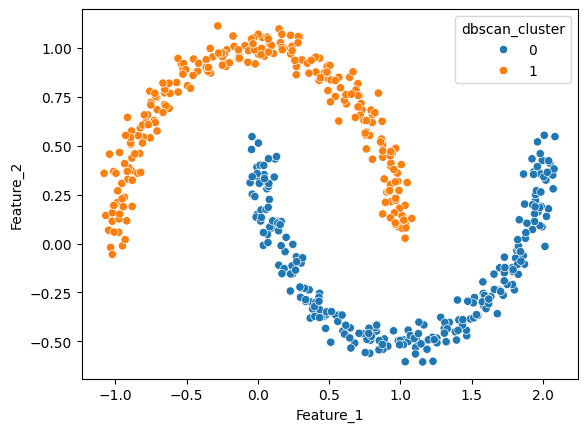

In [272]:
sns.scatterplot(x=df["Feature_1"],
                y=df["Feature_2"],
                hue=df["dbscan_cluster"],
                palette="tab10")

PCA

In [273]:
x,y=make_blobs(n_samples=500,n_features=5,centers=3,cluster_std=1.5,random_state=42)

In [274]:
sc=StandardScaler()
x_scaled=sc.fit_transform(x)


In [275]:
df

,Feature_1,Feature_2,cluster,dbscan_cluster
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,2,1
4,0.293226,1.057185,0,1
...,...,...,...,...
495,0.239754,0.985462,0,1
496,0.072145,0.184834,2,0
497,0.590273,-0.365577,1,0
498,1.619465,-0.283658,1,0


In [ ]:
df_pca=pd.DataFrame(x, columns=["Pca_1","pca_2"])
df_pca["label"]=y

ValueError: Shape of passed values is (500, 5), indices imply (500, 2)